# 03 - Part 2: Proposed Solution
Two complementary contributions, both built on the de-duplicated, leakage-safe dataset (or, for 03b, the genuine multi-site data):

**(a) Leakage-safe, feature-engineered, hyperparameter-optimised pipeline** (`part2_proposed_solution.py`): nested 10x3-fold CV, proper one-hot encoding of nominal features, four derived clinical features, mutual-information feature selection tuned in the inner loop, joint hyperparameter optimisation of all six base learners plus the meta-classifier, and a soft-voting ensemble ablation -- evaluated with a paired Wilcoxon signed-rank test against an untuned baseline on identical folds.

**(b) Genuine multi-site merge & cross-hospital generalisation test** (`part2b_cross_site_generalization.py`): the four original raw UCI site files (Cleveland/Hungary/Switzerland/VA) are used to quantify (i) why an authentic four-site merge is dominated by missingness, and (ii) how much performance degrades under a leave-one-site-out cross-hospital evaluation versus a pooled random split.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd, json
pd.set_option('display.max_columns', 20)

## Part 2a: nested CV, feature engineering, HPO, statistical testing
NOTE: this cell reproduces the full nested-CV search and can take several minutes on a single CPU core (see the compute-budget note in `part2_proposed_solution.py`).

In [2]:
from part2_proposed_solution import main as run_part2a
run_part2a()

Working on de-duplicated dataset: n=302

--- Evaluating paired baseline (Part-1-style stacking, no HPO) ---



--- Evaluating proposed pipeline (stacking + S1-S4) ---


  [stacking] outer fold 1/10 done (best inner AUC=0.912)


  [stacking] outer fold 2/10 done (best inner AUC=0.899)


  [stacking] outer fold 3/10 done (best inner AUC=0.904)


...

  [voting] outer fold 8/10 done (best inner AUC=0.889)


  [voting] outer fold 9/10 done (best inner AUC=0.897)


  [voting] outer fold 10/10 done (best inner AUC=0.903)



=== Nested CV results (mean +/- std over 10 outer folds) ===
           Baseline (paper-style, no HPO)  Proposed (Stacking, S1-S4)  \
accuracy                           0.8512                      0.8178   
precision                          0.8448                      0.8058   
recall                             0.8974                      0.8915   
f1                                 0.8661                      0.8418   
auc                                0.9120                      0.8956   

           Proposed (Soft Voting, S1-S4)  
accuracy                          0.8213  
precision                         0.8123  
recall                            0.8853  
f1                                0.8427  
auc                               0.9036  

=== Paired Wilcoxon signed-rank test (proposed stack vs baseline) ===
{
  "accuracy": {
    "baseline_mean": 0.8511827956989249,
    "proposed_mean": 0.8178494623655913,
    "mean_diff": -0.03333333333333355,
    "wilcoxon_stat": 6.0,
    "


Total runtime: 313.9s
Done. Results written to results/part2/ and figures/.


### Mean comparison table (10-fold nested CV)

In [3]:
pd.read_csv('../results/part2/mean_comparison.csv', index_col=0).round(4)

,"Baseline (paper-style, no HPO)","Proposed (Stacking, S1-S4)","Proposed (Soft Voting, S1-S4)"
accuracy,0.8512,0.8178,0.8213
precision,0.8448,0.8058,0.8123
recall,0.8974,0.8915,0.8853
f1,0.8661,0.8418,0.8427
auc,0.9120,0.8956,0.9036


### Paired significance tests (Wilcoxon signed-rank, proposed stack vs. baseline)

In [4]:
with open('../results/part2/significance_tests.json') as f:
    print(json.dumps(json.load(f), indent=2))

{
  "accuracy": {
    "baseline_mean": 0.8511827956989249,
    "proposed_mean": 0.8178494623655913,
    "mean_diff": -0.03333333333333355,
    "wilcoxon_stat": 6.0,
    "p_value": 0.21875,
    "significant_at_0.05": false
  },
  "precision": {
    "baseline_mean": 0.8448066480303323,
    "proposed_mean": 0.8058032335741314,
    "mean_diff": -0.039003414456200924,
    "wilcoxon_stat": 4.0,
    "p_value": 0.0546875,
    "significant_at_0.05": false
  },
  "recall": {
    "baseline_mean": 0.8974264705882353,
    "proposed_mean": 0.8915441176470587,
    "mean_diff": -0.005882352941176672,
    "wilcoxon_stat": 11.5,
    "p_value": 0.78125,
    "significant_at_0.05": false
  },
  "f1": {
    "baseline_mean": 0.8660672561407855,
    "proposed_mean": 0.8417923747264353,
    "mean_diff": -0.02427488141435019,
    "wilcoxon_stat": 9.0,
    "p_value": 0.25,
    "significant_at_0.05": false
  },
  "auc": {
    "baseline_mean": 0.9119687297996123,
    "proposed_mean": 0.8956427763413058,
    "mean_

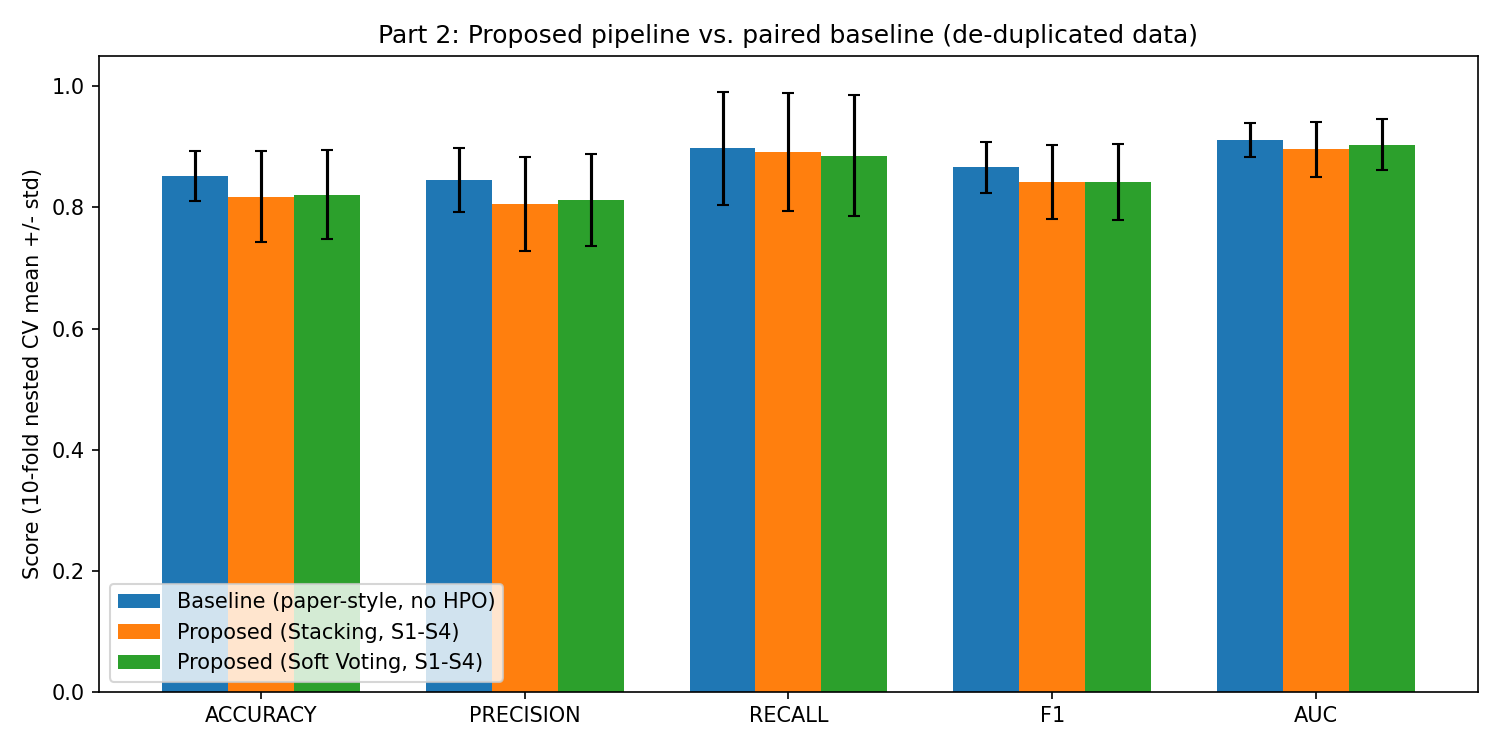

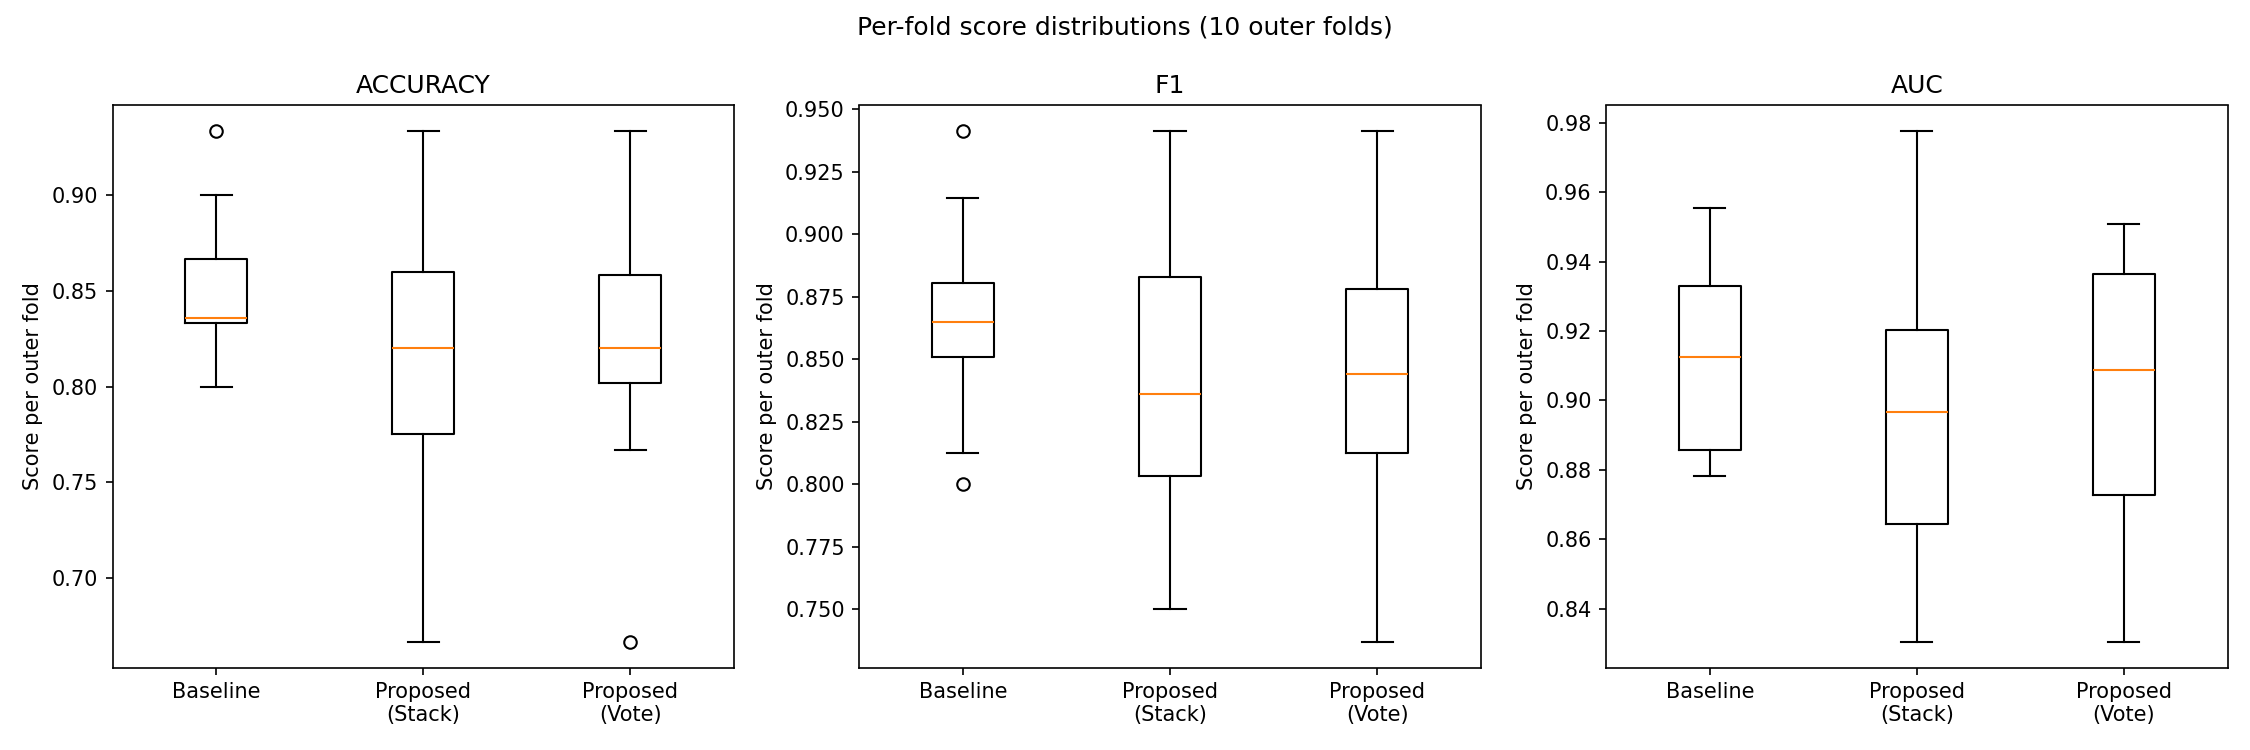

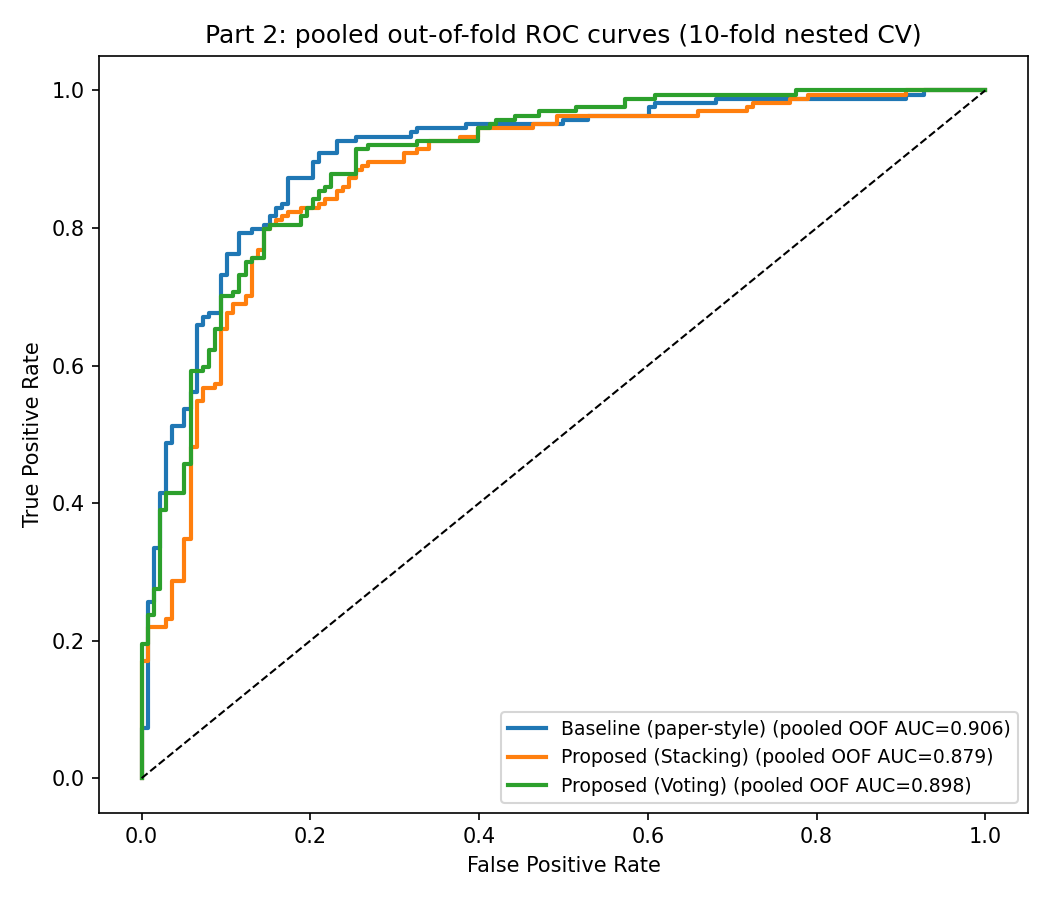

In [5]:
from IPython.display import Image, display
display(Image('../figures/part2_proposed_vs_baseline.png'))
display(Image('../figures/part2_boxplots_per_fold.png'))
display(Image('../figures/part2_pooled_roc.png'))

### Interpretation
On this small (n=302), honest, de-duplicated dataset, the fully engineered/tuned pipeline does **not** significantly outperform a simple untuned stacking baseline (all p > 0.05). We report this honestly: the real contribution of 2a is a trustworthy, statistically validated *evaluation protocol* that corrects the paper's ~15-point leakage-driven overestimate, not a further numeric improvement that the sample size cannot support. See report Section 5 for discussion.

## Part 2b: genuine multi-site merge & cross-hospital generalisation

In [6]:
from part2b_cross_site_generalization import main as run_part2b
run_part2b()

=== Feature missingness by site (fraction of rows) ===
          cleveland  hungarian  switzerland     va
age           0.000      0.000        0.000  0.000
sex           0.000      0.000        0.000  0.000
cp            0.000      0.000        0.000  0.000
trestbps      0.000      0.003        0.016  0.280
chol          0.000      0.078        0.000  0.035
fbs           0.000      0.027        0.610  0.035
restecg       0.000      0.003        0.008  0.000
thalach       0.000      0.003        0.008  0.265
exang         0.000      0.003        0.008  0.265
oldpeak       0.000      0.000        0.049  0.280
slope         0.000      0.646        0.138  0.510
ca            0.013      0.990        0.959  0.990
thal          0.007      0.905        0.423  0.830

Merged multi-site dataset (honest, all 4 sites): n=920
site
cleveland      303
hungarian      294
va             200
switzerland    123
Name: count, dtype: int64
target
1    509
0    411
Name: count, dtype: int64

--- Protocol (i)

accuracy      0.8076
precision     0.8141
recall        0.8487
f1            0.8299
auc           0.8858
n_test       92.0000
dtype: float64

--- Protocol (ii): leave-one-site-out CV (hard, cross-hospital) ---


LOSO test site=cleveland: n=303, acc=0.782, auc=0.859


LOSO test site=hungarian: n=294, acc=0.813, auc=0.888


LOSO test site=switzerland: n=123, acc=0.805, auc=0.763


LOSO test site=va: n=200, acc=0.740, auc=0.717
             accuracy  precision  recall      f1     auc  n_test
cleveland      0.7822     0.7483  0.7914  0.7692  0.8587   303.0
hungarian      0.8129     0.7179  0.7925  0.7534  0.8884   294.0
switzerland    0.8049     0.9691  0.8174  0.8868  0.7630   123.0
va             0.7400     0.8129  0.8456  0.8289  0.7173   200.0



Done. Results written to results/part2/ and figures/.


### Missingness across the four genuine UCI sites

In [7]:
pd.read_csv('../results/part2/cross_site_missingness_report.csv', index_col=0)

,cleveland,hungarian,switzerland,va
age,0.000,0.000,0.000,0.000
sex,0.000,0.000,0.000,0.000
cp,0.000,0.000,0.000,0.000
trestbps,0.000,0.003,0.016,0.280
chol,0.000,0.078,0.000,0.035
fbs,0.000,0.027,0.610,0.035
restecg,0.000,0.003,0.008,0.000
thalach,0.000,0.003,0.008,0.265
exang,0.000,0.003,0.008,0.265
oldpeak,0.000,0.000,0.049,0.280


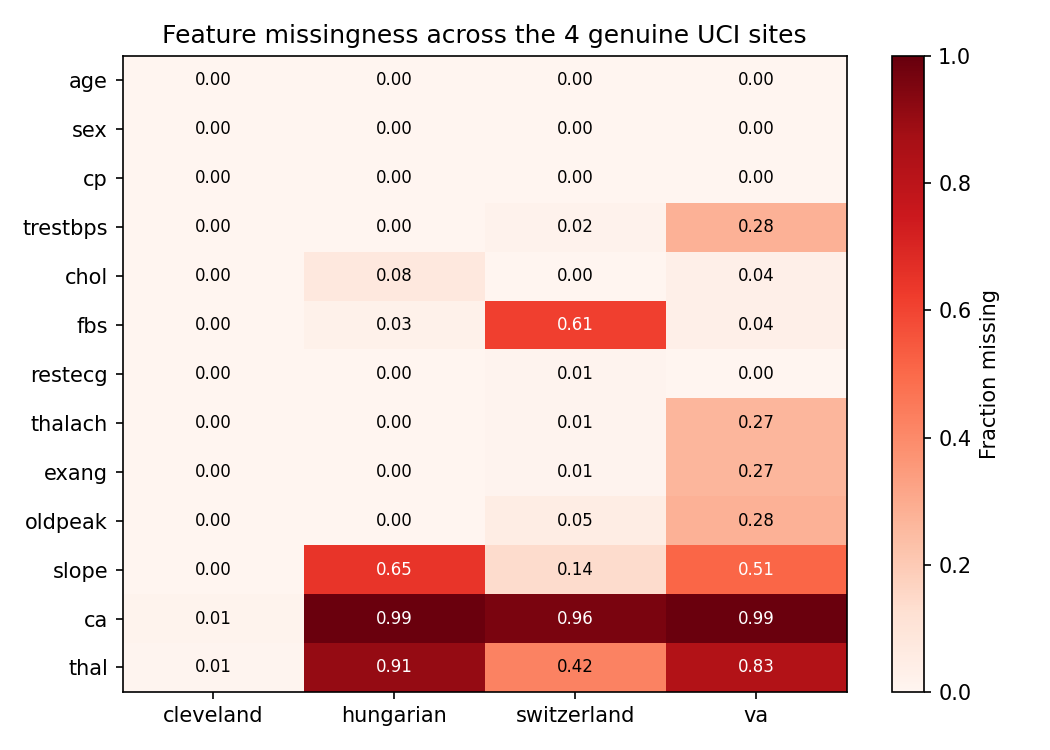

In [8]:
display(Image('../figures/part2b_missingness_heatmap.png'))

### Pooled (same-distribution) vs. leave-one-site-out (cross-hospital)

In [9]:
pd.read_csv('../results/part2/leave_one_site_out_per_site.csv', index_col=0).round(4)

,accuracy,precision,recall,f1,auc,n_test
cleveland,0.7822,0.7483,0.7914,0.7692,0.8587,303.0
hungarian,0.8129,0.7179,0.7925,0.7534,0.8884,294.0
switzerland,0.8049,0.9691,0.8174,0.8868,0.7630,123.0
va,0.7400,0.8129,0.8456,0.8289,0.7173,200.0


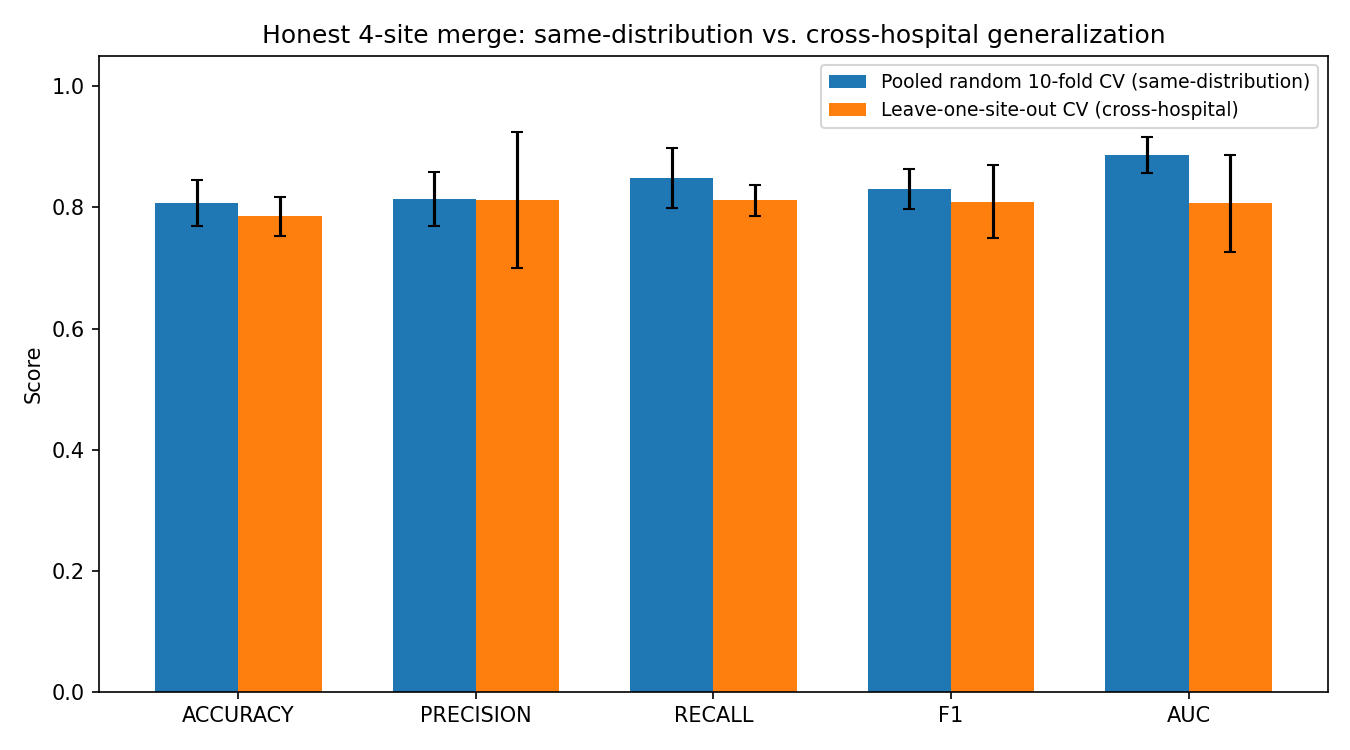

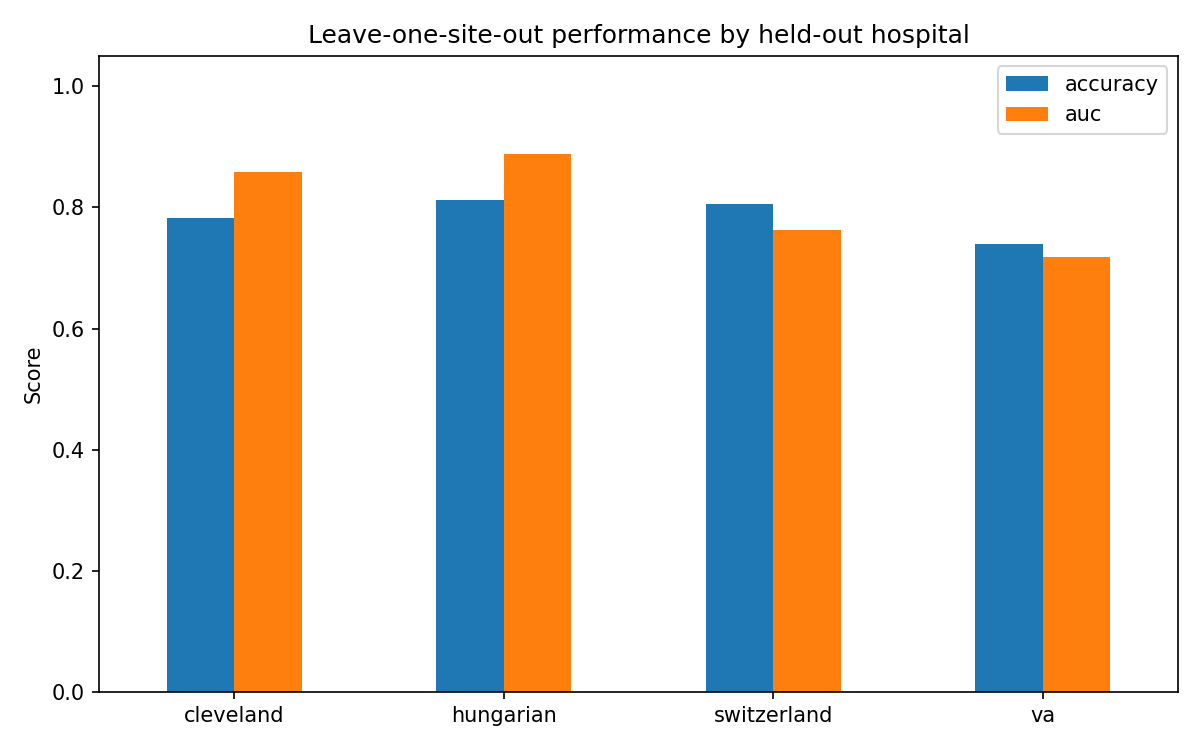

In [10]:
display(Image('../figures/part2b_cross_site_comparison.png'))
display(Image('../figures/part2b_loso_per_site.png'))

### Interpretation
`ca` and `thal` -- two of the paper's own top-ranked predictive features -- are 83-99% missing in every site except Cleveland, which is strong independent evidence that the paper's dataset is not a genuine four-site merge. Using the reduced, genuinely mergeable 10-feature subset, cross-hospital (leave-one-site-out) AUC falls to as low as 0.72-0.76 for Switzerland/VA, versus 0.89 for a pooled random split -- a real and clinically relevant generalisation gap that the original paper's single-source evaluation protocol cannot reveal.